In [1]:
from dataMaker import DataHandler
import plotter
import dataLoader
import config

import torch
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

### Data Paths

In [2]:
data_dir = '/workspace/data/'

# Simulated data
train_data = data_dir + '/grid_data_atten_big_train.h5'
val_data = data_dir + '/grid_data_atten_big_val.h5'
test_data = data_dir + '/grid_data_atten_big_test.h5'
mat_data = data_dir + '/grid_data_atten.mat'
mat_noise = data_dir + '/noise_only_data_atten.mat'

# Experimental data
warped_dir = data_dir + '/warped_calls_D72_cb1461'
collected_data = data_dir + '/call_collection'
exp_data = data_dir + '/wav_calls.h5'

max_range = config.max_range

## Simulated Data

### Generate Spectrogams

Here we generate spectrograms from the .mat files which contain the results of the [KRAKEN](https://oalib-acoustics.org/models-and-software/normal-modes/) simulation.

In [3]:
# Load simulated data into data object
handler = DataHandler(path=config.mat_data, noise_only_path=config.mat_noise)

# Make each audio waveform have mean=0 and var=1
handler.normalize_wav()

# Create spectrograms
#handler.create_spectrograms(rand_shift=True, nperseg=62, noverlap=46, nfft=451, verbose=True);
handler.create_signals(rand_shift=True, verbose=True);

  0%|          | 0/741920 [00:00<?, ?it/s]

In [4]:
print("Saving")
# Save data
handler.save_split_h5(train_path=config.train_data, 
                      val_path=config.val_data, 
                      test_path=config.test_data, 
                      train_size=0.8, 
                      test_size=0.1, 
                      val_size=0.1, 
                      shuffle=True)

del handler

Saving
Splitting Data...
Saving Training Data...
(20000, 3600)
(30000, 3600)
(40000, 3600)
(50000, 3600)
(60000, 3600)
(70000, 3600)
(80000, 3600)
(90000, 3600)
(100000, 3600)
(110000, 3600)
(120000, 3600)
(130000, 3600)
(140000, 3600)
(150000, 3600)
(160000, 3600)
(170000, 3600)
(180000, 3600)
(190000, 3600)
(200000, 3600)
(210000, 3600)
(220000, 3600)
(230000, 3600)
(240000, 3600)
(250000, 3600)
(260000, 3600)
(270000, 3600)
(280000, 3600)
(290000, 3600)
(300000, 3600)
(310000, 3600)
(320000, 3600)
(330000, 3600)
(340000, 3600)
(350000, 3600)
(360000, 3600)
(370000, 3600)
(380000, 3600)
(390000, 3600)
(400000, 3600)
(410000, 3600)
(420000, 3600)
(430000, 3600)
(440000, 3600)
(450000, 3600)
(460000, 3600)
(470000, 3600)
Saving Test Data...
(20000, 3600)
(30000, 3600)
(40000, 3600)
(50000, 3600)
(60000, 3600)
(70000, 3600)
Saving Validation Data
(20000, 3600)
(30000, 3600)
(40000, 3600)
(50000, 3600)
(60000, 3600)
(70000, 3600)


### Visualize Data

Load the validation data.

In [5]:
X, y = dataLoader.load_h5(test_data)

Show some distributions of simulation parameters. These could be NOT uniform if the duration filer was used during simulation.

Text(0, 0.5, 'Number of Examples')

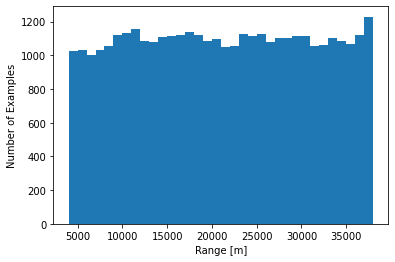

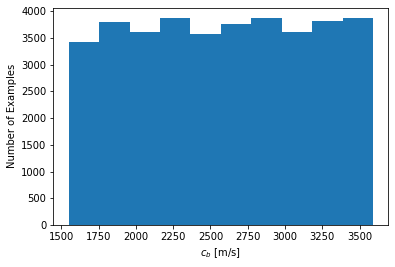

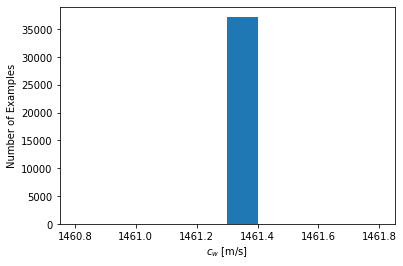

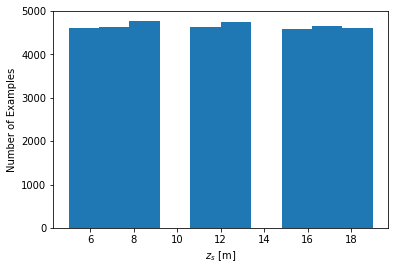

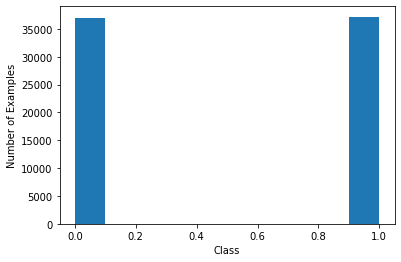

In [6]:
plt.figure()
plt.hist(y[y[:,0] != -1, 0], bins='auto')
plt.xlabel("Range [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,1] != -1, 1])
plt.xlabel("$c_{b}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,2] != -1, 2])
plt.xlabel("$c_{w}$ [m/s]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,3] != -1, 3])
plt.xlabel("$z_{s}$ [m]")
plt.ylabel("Number of Examples")

plt.figure()
plt.hist(y[y[:,4] != -1, 4])
plt.xlabel("Class")
plt.ylabel("Number of Examples")

In [16]:
X = X[y[:,0] == 5200]
y = y[y[:,0] == 5200]

Plot the different classes

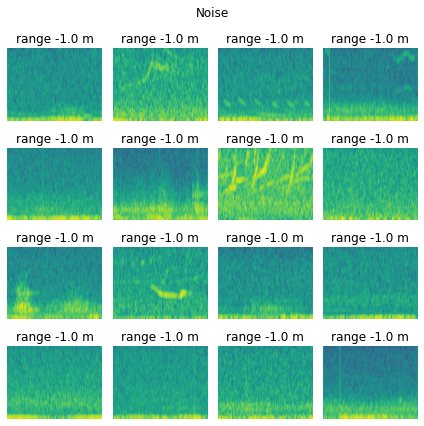

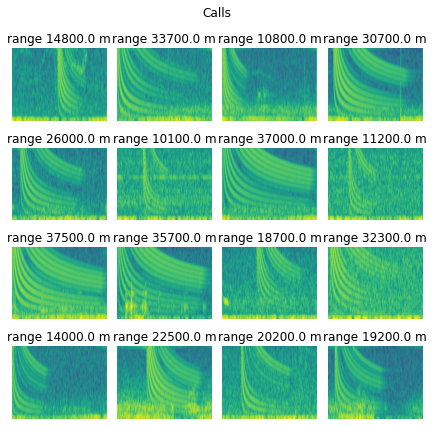

In [7]:
# Plot examples from noise class
plotter.plot_grid(X[np.where(y[:,4] == 0)], y[np.where(y[:,4] == 0),0].squeeze(), label_text="range", title="Noise", dim=(4,4))

# Plot examples from call class
plotter.plot_grid(X[np.where(y[:,4] == 1)], y[np.where(y[:,4] == 1),0].squeeze(), label_text="range", title="Calls", dim=(4,4))

### Get Training Set Statistics

In [12]:
# Create dataset and dataloader
dataset = dataLoader.Gunshot(dir_path=train_data, max_range=max_range)
dataloader = data.DataLoader(dataset, batch_size=128, drop_last=False, shuffle=True, num_workers=28)

In [9]:
from tqdm.notebook import tqdm

# Placeholders
psum = torch.tensor([0.0])
psum_sq = torch.tensor([0.0])

# Calculate sum of data and sum of squared data
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,2,3))
    psum_sq += (inputs ** 2).sum(axis=(0,2,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.imsize[0]*dataset.imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

  0%|          | 0/3710 [00:00<?, ?it/s]

mean:  tensor([-30.1798])
std:  tensor([12.0857])


## Experimental Data

### Generate Spectrograms

In [3]:
# Load experimental data into data object
handler = DataHandler(path=warped_dir, data_dir=data_dir, mode='wav', fs_desired=600)

# Make each audio waveform have mean=0 and var=1
handler.normalize_wav()

# Create spectrograms
#handler.create_spectrograms(rand_shift=False, nperseg=62, noverlap=46, nfft=451, verbose=True)
handler.create_signals(rand_shift=False, verbose=True);

# Save data
handler.save_h5(exp_data)

del handler

  0%|          | 0/93 [00:00<?, ?it/s]

### Visualize Data

Load the experimental warped data.

In [11]:
X_w, y_w = dataLoader.load_h5(exp_data)

In [13]:
X_w = X_w[y_w[:,0] == 5500,:]
y_w = y_w[y_w[:,0] == 5500,:]

Plot some samples.

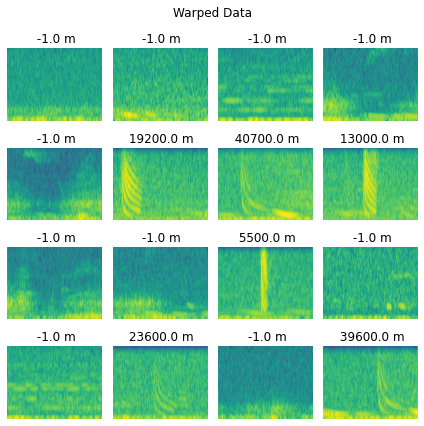

In [12]:
# Make plot
plotter.plot_grid(X_w, y_w[:,0], label_text="", title="Warped Data", dim=(4,4), randomize=False)

In [8]:
dataset = dataLoader.Gunshot(dir_path=val_data, max_range=max_range, transform=dataLoader.get_image_transforms()['train'])
dataloader = data.DataLoader(dataset, batch_size=128, drop_last=False, shuffle=True, num_workers=28)

In [9]:
a = next(iter(dataloader))
i = a[0]
r = a[1]

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/opt/conda/lib/python3.8/site-packages/torch/utils/data/_utils/worker.py", line 287, in _worker_loop
    data = fetcher.fetch(index)
  File "/opt/conda/lib/python3.8/site-packages/torch/utils/data/_utils/fetch.py", line 49, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/opt/conda/lib/python3.8/site-packages/torch/utils/data/_utils/fetch.py", line 49, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/workspace/6.869_final_project/dataLoader.py", line 83, in __getitem__
    inputs = self.transform(inputs)
  File "/opt/conda/lib/python3.8/site-packages/torchvision/transforms/transforms.py", line 95, in __call__
    img = t(img)
  File "/workspace/6.869_final_project/data_augmentation.py", line 88, in __call__
    return self.freq_band_zeroing(tensor)
  File "/workspace/6.869_final_project/data_augmen

In [5]:
plotter.plot_grid(X_w, y_w[:,0], label_text="", title="Warped Data", dim=(4,4), randomize=False)

tensor([[[-30.1647, -31.4195, -34.5054,  ..., -40.3707, -37.7275, -36.7957],
         [-30.1198, -31.3500, -34.4561,  ..., -40.4646, -37.7885, -36.8411],
         [-30.0345, -31.2140, -34.3436,  ..., -40.6546, -37.9130, -36.9271],
         ...,
         [ -2.9004,  -1.0489,  -0.5437,  ...,  -7.4811,  -5.8327,  -6.4691],
         [ -2.8242,  -0.9443,  -0.4128,  ...,  -7.8242,  -5.8603,  -6.4383],
         [ -2.7988,  -0.9094,  -0.3692,  ...,  -7.9512,  -5.8704,  -6.4281]]])